In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from collections import defaultdict

In [10]:
base_dir = Path("/Users/chiyune/Desktop/project/ns-3/results-wns3")
queue_files = sorted(base_dir.glob("unfair-0008-tcp-all-flow-OLIA08-*/scheduler*-rx-ltenr-tcp.txt"))

records = []
for file in queue_files:
    df = pd.read_csv(file, sep="\t", header=None, names=[
        "flowId", "time", "rxBytes", "rxPackets", "lastDelay_ms", "throughput_Mbps"
    ])
    df = df[df["flowId"].isin([9, 10])]
    df["filename"] = file.name
    # 從檔名中提取scheduler編號
    scheduler_match = re.search(r"scheduler(\d+)-rx", file.name)
    if scheduler_match:
        scheduler_id = int(scheduler_match.group(1))
        df["scheduler"] = scheduler_id
    records.append(df)


In [11]:
records

[      flowId   time  rxBytes  rxPackets  lastDelay_ms  throughput_Mbps  \
 240        9   2.00        0          0             0              NaN   
 241       10   2.00        0          0             0              NaN   
 250        9   2.05     9516         18            13          0.00000   
 251       10   2.05     5988         12            18          0.00000   
 262        9   2.10    31860         56            35          0.00000   
 ...      ...    ...      ...        ...           ...              ...   
 6923      10  29.85  2923572       4976            12          4.44823   
 6934       9  29.90  2875892       4894             5          4.00417   
 6935      10  29.90  2923572       4976            12          4.44823   
 6946       9  29.95  2875892       4894             5          4.00417   
 6947      10  29.95  2923572       4976            12          4.44823   
 
                          filename  scheduler  
 240   scheduler0-rx-ltenr-tcp.txt          0  
 2

In [12]:
# 3. 合併所有檔案資料
df_all = pd.concat(records, ignore_index=True)

# 4. 算每個檔案 + flow 的 delay 總和、平均
summary = df_all.groupby(["filename", "flowId"]).agg(
    total_delay_ms=("lastDelay_ms", "sum"),
    avg_delay_ms=("lastDelay_ms", "mean"),
    sample_count=("lastDelay_ms", "count")
).reset_index()

In [13]:
df_all

,flowId,time,rxBytes,rxPackets,lastDelay_ms,throughput_Mbps,filename,scheduler
0,9,2.00,0,0,0,NaN,scheduler0-rx-ltenr-tcp.txt,0
1,10,2.00,0,0,0,NaN,scheduler0-rx-ltenr-tcp.txt,0
2,9,2.05,9516,18,13,0.00000,scheduler0-rx-ltenr-tcp.txt,0
3,10,2.05,5988,12,18,0.00000,scheduler0-rx-ltenr-tcp.txt,0
4,9,2.10,31860,56,35,0.00000,scheduler0-rx-ltenr-tcp.txt,0
...,...,...,...,...,...,...,...,...
556206,10,29.85,2876480,4895,11,3.54511,scheduler4-rx-ltenr-tcp.txt,4
556207,9,29.90,2877480,4897,5,4.91302,scheduler4-rx-ltenr-tcp.txt,4
556208,10,29.90,2876480,4895,11,3.54511,scheduler4-rx-ltenr-tcp.txt,4
556209,9,29.95,2877480,4897,5,4.91302,scheduler4-rx-ltenr-tcp.txt,4


In [14]:
summary

,filename,flowId,total_delay_ms,avg_delay_ms,sample_count
0,scheduler0-rx-ltenr-tcp.txt,9,610197,10.989590,55525
1,scheduler0-rx-ltenr-tcp.txt,10,646578,11.764948,54958
2,scheduler1-rx-ltenr-tcp.txt,9,535651,9.565538,55998
3,scheduler1-rx-ltenr-tcp.txt,10,664755,11.991612,55435
4,scheduler2-rx-ltenr-tcp.txt,9,509608,9.100468,55998
5,scheduler2-rx-ltenr-tcp.txt,10,651744,11.757329,55433
6,scheduler3-rx-ltenr-tcp.txt,9,496629,8.868692,55998
7,scheduler3-rx-ltenr-tcp.txt,10,658310,11.875350,55435
8,scheduler4-rx-ltenr-tcp.txt,9,473055,8.447712,55998
9,scheduler4-rx-ltenr-tcp.txt,10,652642,11.773528,55433


In [17]:
df_part = df_all[["flowId", "lastDelay_ms", "scheduler"]]
df_part

,flowId,lastDelay_ms,scheduler
0,9,0,0
1,10,0,0
2,9,13,0
3,10,18,0
4,9,35,0
...,...,...,...
556206,10,11,4
556207,9,5,4
556208,10,11,4
556209,9,5,4


In [21]:
# 根據scheduler分組計算平均延遲
scheduler_summary = df_all.groupby("scheduler")["lastDelay_ms"].agg([
    ("平均延遲", "mean"),
    ("最大延遲", "max")
]).round(2)

print("各排程器的延遲統計:")
print(scheduler_summary)


各排程器的延遲統計:
            平均延遲  最大延遲
scheduler             
0          11.38   331
1          10.77   361
2          10.42   342
3          10.36   348
4          10.10   361


<Figure size 1200x600 with 0 Axes>

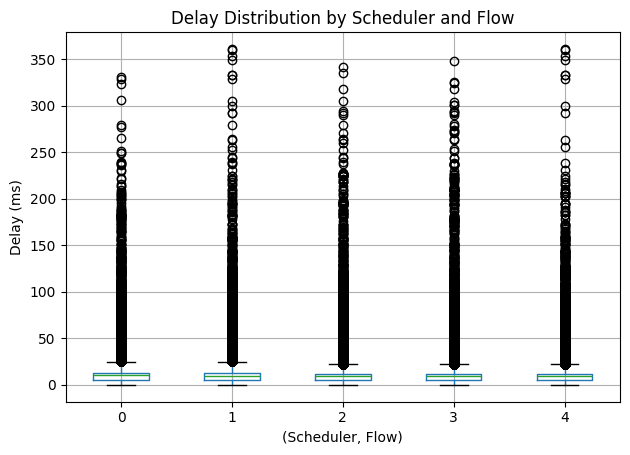

In [25]:
# 畫 box plot, x軸為 scheduler 編號
plt.figure(figsize=(12, 6))
df_part.boxplot(column='lastDelay_ms', by='scheduler')
plt.title('Delay Distribution by Scheduler and Flow')
plt.xlabel('(Scheduler, Flow)')
plt.ylabel('Delay (ms)')
plt.suptitle('')  # 移除自動產生的標題
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
